<a href="https://colab.research.google.com/github/mikikonomiya/olympic-data-analysis/blob/main/rising_athlethes_age.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. LOAD LIBRARIES
library(ggplot2)
library(tidyverse)

olympic_data <- read.csv("/content/athlete_events.csv")

In [ ]:
# 1. Create the two groups
early_era <- olympic_data %>%
  filter(Year >= 1960 & Year <= 1976, !is.na(Age))

recent_era <- olympic_data %>%
  filter(Year >= 2000 & Year <= 2016, !is.na(Age))

# 2. Perform the t-test (Welch's t-test is safest as it doesn't assume equal variance)
t_test_result <- t.test(recent_era$Age, early_era$Age)

# 3. Print results
print(t_test_result)


	Welch Two Sample t-test

data:  recent_era$Age and early_era$Age
t = 43.279, df = 103224, p-value < 2.2e-16
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 1.302595 1.426173
sample estimates:
mean of x mean of y 
 25.83422  24.46983 



Warning message:
“Removed 325 rows containing non-finite outside the scale range
(`stat_density()`).”


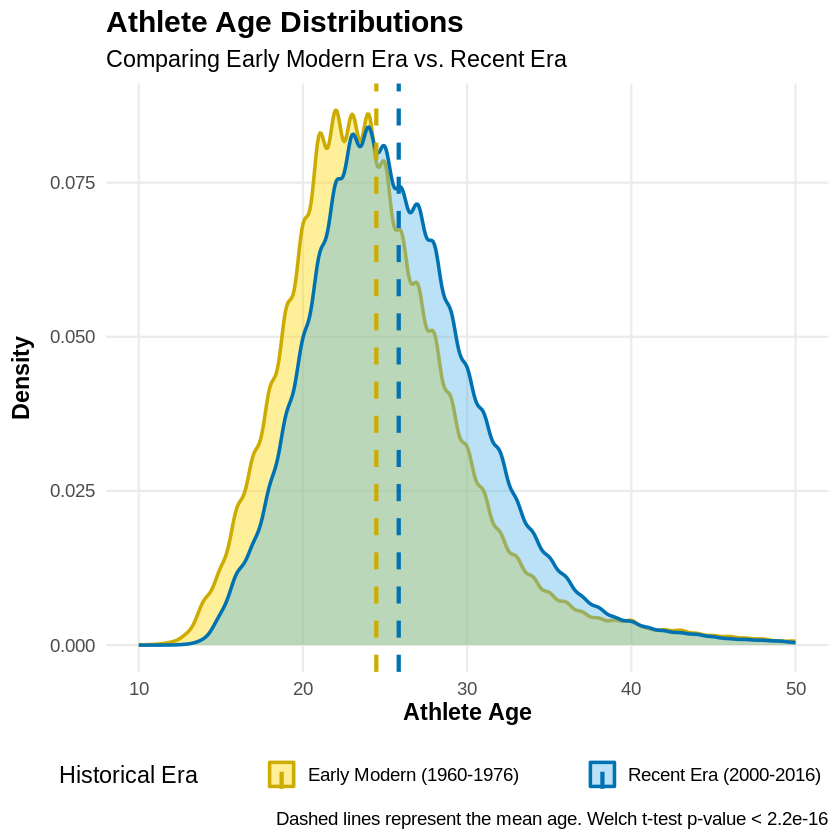

In [ ]:
# 2. Filter and Label the Eras
plot_data <- olympic_data %>%
  filter(!is.na(Age)) %>%
  mutate(Era = case_when(
    Year >= 1960 & Year <= 1976 ~ "Early Modern (1960-1976)",
    Year >= 2000 & Year <= 2016 ~ "Recent Era (2000-2016)",
    TRUE ~ NA_character_
  )) %>%
  filter(!is.na(Era))

# 3. Calculate the exact means for the vertical lines
# This visually proves your t-test results
means <- plot_data %>%
  group_by(Era) %>%
  summarize(mean_age = mean(Age))

# 4. Create the Plot
ggplot(plot_data, aes(x = Age, fill = Era, color = Era)) +
  # Density curves with transparency (alpha)
  geom_density(alpha = 0.4, linewidth = 1) +

  # Vertical lines to mark the mean "Peak"
  geom_vline(data = means, aes(xintercept = mean_age, color = Era),
             linetype = "dashed", linewidth = 1.2) +

  # Setting your Blue/Yellow Colors
  # #FFD700 is a nice Gold/Yellow; #56B4E9 is a clean Light Blue
  scale_fill_manual(values = c("Early Modern (1960-1976)" = "#FFD700",
                               "Recent Era (2000-2016)" = "#56B4E9")) +
  scale_color_manual(values = c("Early Modern (1960-1976)" = "#CCAC00",
                                "Recent Era (2000-2016)" = "#0072B2")) +

  # Aesthetic Improvements for Presentation
  labs(title = "Athlete Age Distributions",
       subtitle = "Comparing Early Modern Era vs. Recent Era",
       x = "Athlete Age",
       y = "Density",
       fill = "Historical Era",
       color = "Historical Era",
       caption = "Dashed lines represent the mean age. Welch t-test p-value < 2.2e-16") +
  theme_minimal(base_size = 14) + # Larger text for visibility
  theme(
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 18),
    panel.grid.minor = element_blank(),
    axis.title = element_text(face = "bold")
  ) +
  # Zooming in on the main range (optional, helps focus on the curve)
  xlim(10, 50)